In [1]:
%pip install kagglehub pyarrow xgboost tensorflow scikit-learn tensorflow


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhoogla/unswnb15")

print("Path to dataset files:", path)

/Users/mpersson/COMP9150/proj2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/mpersson/.cache/kagglehub/datasets/dhoogla/unswnb15/versions/5



Training set shape: (175341, 36)
Testing set shape: (82332, 36)

--- Head ---


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-n

Series([], dtype: int64)


--- Duplicate rows ---
78519

--- Numeric summary ---


...

,count,unique,top,freq
proto,175341,133,tcp,79946
service,175341,13,-,94168
state,175341,9,INT,82275
attack_cat,175341,10,Normal,56000



--- Value counts: label ---


label
1    119341
0     56000
Name: count, dtype: int64


--- Value counts: attack_cat ---


attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

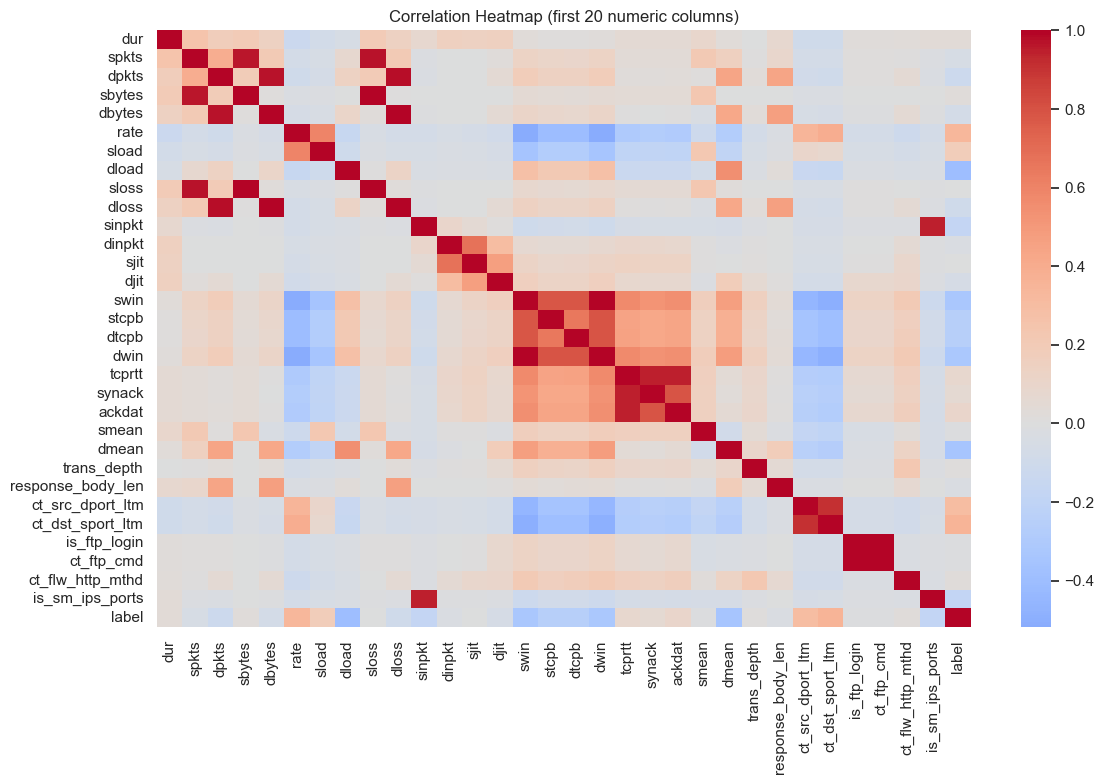

In [3]:
import os
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

test_df = pd.read_parquet(os.path.join(path, "UNSW_NB15_testing-set.parquet"))
train_df = pd.read_parquet(os.path.join(path, "UNSW_NB15_training-set.parquet"))

print("\nTraining set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

# Quick EDA of the training set
print("\n--- Head ---")
display(train_df.head())

print("\n--- Info ---")
train_df.info()

print("\n--- Missing values (top 20) ---")
missing = train_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

print("\n--- Duplicate rows ---")
print(train_df.duplicated().sum())

print("\n--- Numeric summary ---")
display(train_df.describe(include=["number"]).T)

print("\n--- Categorical summary ---")
cat_cols = train_df.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    display(train_df[cat_cols].describe().T.head(20))

# Target distribution
for target_col in ["label", "attack_cat", "Class", "class"]:
    if target_col in train_df.columns:
        print(f"\n--- Value counts: {target_col} ---")
        display(train_df[target_col].value_counts(dropna=False).head(20))

# Basic visual EDA
sns.set(style="whitegrid")

# Missing values plot (top 15)
top_missing = missing[missing > 0].head(15)
if not top_missing.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_missing.values, y=top_missing.index, palette="viridis")
    plt.title("Top Missing Columns")
    plt.xlabel("Missing Count")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

# Correlation heatmap for numeric columns
num_cols = train_df.select_dtypes(include=["number"]).columns
if len(num_cols) > 1:
    sample_num_cols = num_cols  # limit for readability
    corr = train_df[sample_num_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (first 20 numeric columns)")
    plt.tight_layout()
    plt.show()

In [4]:
# Check null/NaN values in train and test sets
for name, df in [("train_df", train_df), ("test_df", test_df)]:
    null_counts = df.isna().sum()
    total_nulls = int(null_counts.sum())
    
    print(f"\n{name} -> total null/NaN values: {total_nulls}")
    print(f"{name} -> columns with null/NaN: {(null_counts > 0).sum()}")
    
    if total_nulls > 0:
        display(null_counts[null_counts > 0].sort_values(ascending=False))


train_df -> total null/NaN values: 0
train_df -> columns with null/NaN: 0

test_df -> total null/NaN values: 0
test_df -> columns with null/NaN: 0


In [5]:
from sklearn.preprocessing import StandardScaler

# Drop duplicate rows
train_before, test_before = len(train_df), len(test_df)
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

# Normalize numeric feature columns (fit on train, apply to test)
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
exclude_cols = {"label", "Class", "class"}
if "target" in globals():
    exclude_cols.add(target)

feature_cols = [c for c in numeric_cols if c not in exclude_cols and c in test_df.columns]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols].astype("float64"))
train_df[feature_cols] = pd.DataFrame(train_scaled, columns=feature_cols, index=train_df.index)
    
test_scaled = scaler.transform(test_df[feature_cols].astype("float64"))
test_df[feature_cols] = pd.DataFrame(test_scaled, columns=feature_cols, index=test_df.index)

print(f"Train duplicates removed: {train_before - len(train_df)}")
print(f"Test duplicates removed: {test_before - len(test_df)}")
print(f"Standardized feature count: {len(feature_cols)}")

Train duplicates removed: 78519
Test duplicates removed: 32361
Standardized feature count: 31


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

target = "label"

train_df

y_train = train_df[target]
X_train = train_df.drop(columns=[target, "attack_cat"])

y_test = test_df[target]
X_test = test_df.drop(columns=[target, "attack_cat"])

# Baseline: always predict the most frequent class from training data
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_clf.fit(X_train, y_train)
y_pred = baseline_clf.predict(X_test)

print(f"Target column: {target}")
print(f"Baseline strategy: {baseline_clf.strategy}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Target column: label
Baseline strategy: most_frequent
Accuracy: 0.6326
Balanced Accuracy: 0.5000

Classification report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77     31610
           1       0.00      0.00      0.00     18361

    accuracy                           0.63     49971
   macro avg       0.32      0.50      0.39     49971
weighted avg       0.40      0.63      0.49     49971

Confusion matrix:
[[31610     0]
 [18361     0]]


Attack Type Classification: RandomForestClassifier
Accuracy: 0.9782
Balanced Accuracy: 0.8849

Classification report:
                precision    recall  f1-score   support

      Backdoor       0.53      0.88      0.66       296
       Generic       0.96      0.83      0.89      1643
        Normal       0.99      1.00      0.99     31610
Reconnaissance       0.96      0.83      0.89      2127

      accuracy                           0.98     35676
     macro avg       0.86      0.88      0.86     35676
  weighted avg       0.98      0.98      0.98     35676

Confusion matrix:
[[  261     2    16    17]
 [   31  1363   237    12]
 [    2    53 31505    50]
 [  200     2   156  1769]]


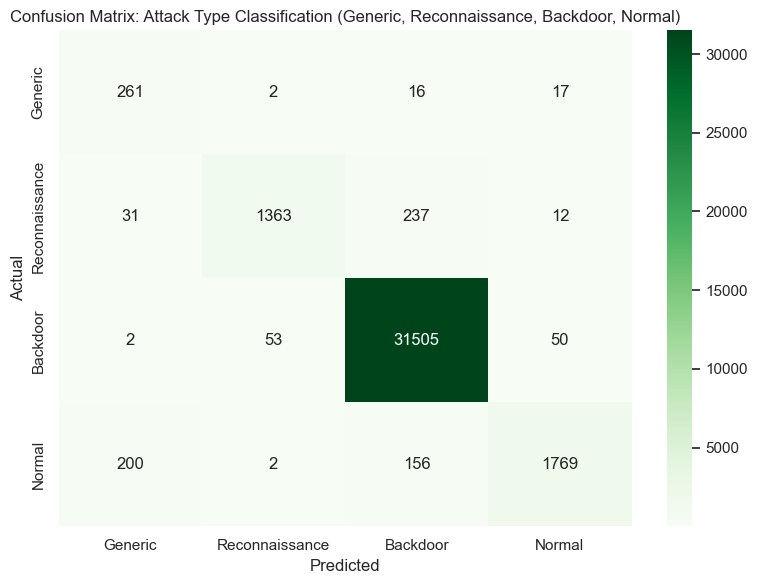

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# One-hot encode categorical features and align train/test columns
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# Filter training data for generic, reconnaissance, backdoor, and normal attacks
attack_types = ['Generic', 'Reconnaissance', 'Backdoor', 'Normal']
train_mask = train_df['attack_cat'].isin(attack_types)
test_mask = test_df['attack_cat'].isin(attack_types)

X_train_filtered = X_train_enc[train_mask]
y_train_filtered = train_df.loc[train_mask, 'attack_cat']

X_test_filtered = X_test_enc[test_mask]
y_test_filtered = test_df.loc[test_mask, 'attack_cat']

# Train Random Forest for attack type classification
rf_attack_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_attack_clf.fit(X_train_filtered, y_train_filtered)

# Predict and evaluate
y_pred_attack = rf_attack_clf.predict(X_test_filtered)

print("Attack Type Classification: RandomForestClassifier")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_attack):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_attack):.4f}")

print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_attack, zero_division=0))

print("Confusion matrix:")
cm_attack = confusion_matrix(y_test_filtered, y_pred_attack)
print(cm_attack)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_attack, annot=True, fmt="d", cmap="Greens", 
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: Attack Type Classification (Generic, Reconnaissance, Backdoor, Normal)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Attack Type Classification: DecisionTreeClassifier
Accuracy: 0.9482
Balanced Accuracy: 0.9150

Classification report:
                precision    recall  f1-score   support

      Backdoor       0.37      0.95      0.54       296
       Generic       0.56      0.92      0.70      1643
        Normal       0.99      0.96      0.98     31610
Reconnaissance       0.97      0.84      0.90      2127

      accuracy                           0.95     35676
     macro avg       0.73      0.91      0.78     35676
  weighted avg       0.97      0.95      0.95     35676

Confusion matrix:
[[ 1504     3    60    76]
 [    8  1782   269    68]
 [    4     2   281     9]
 [ 1155    54   141 30260]]


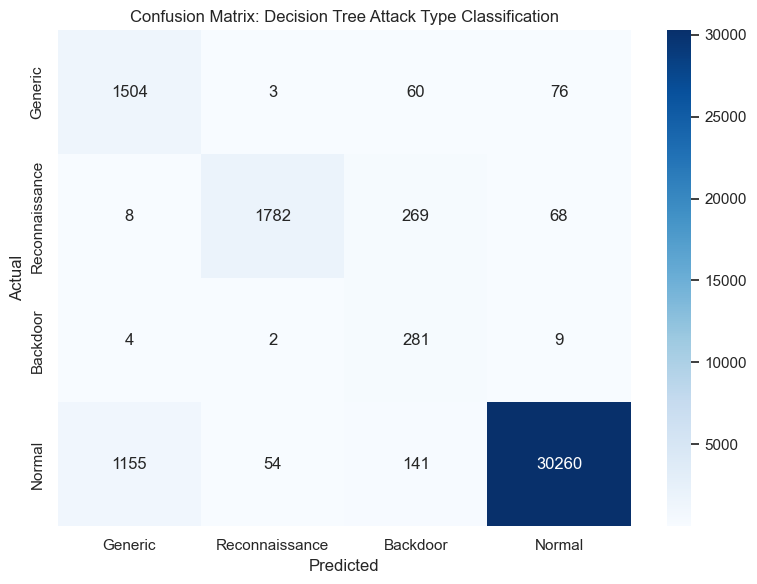

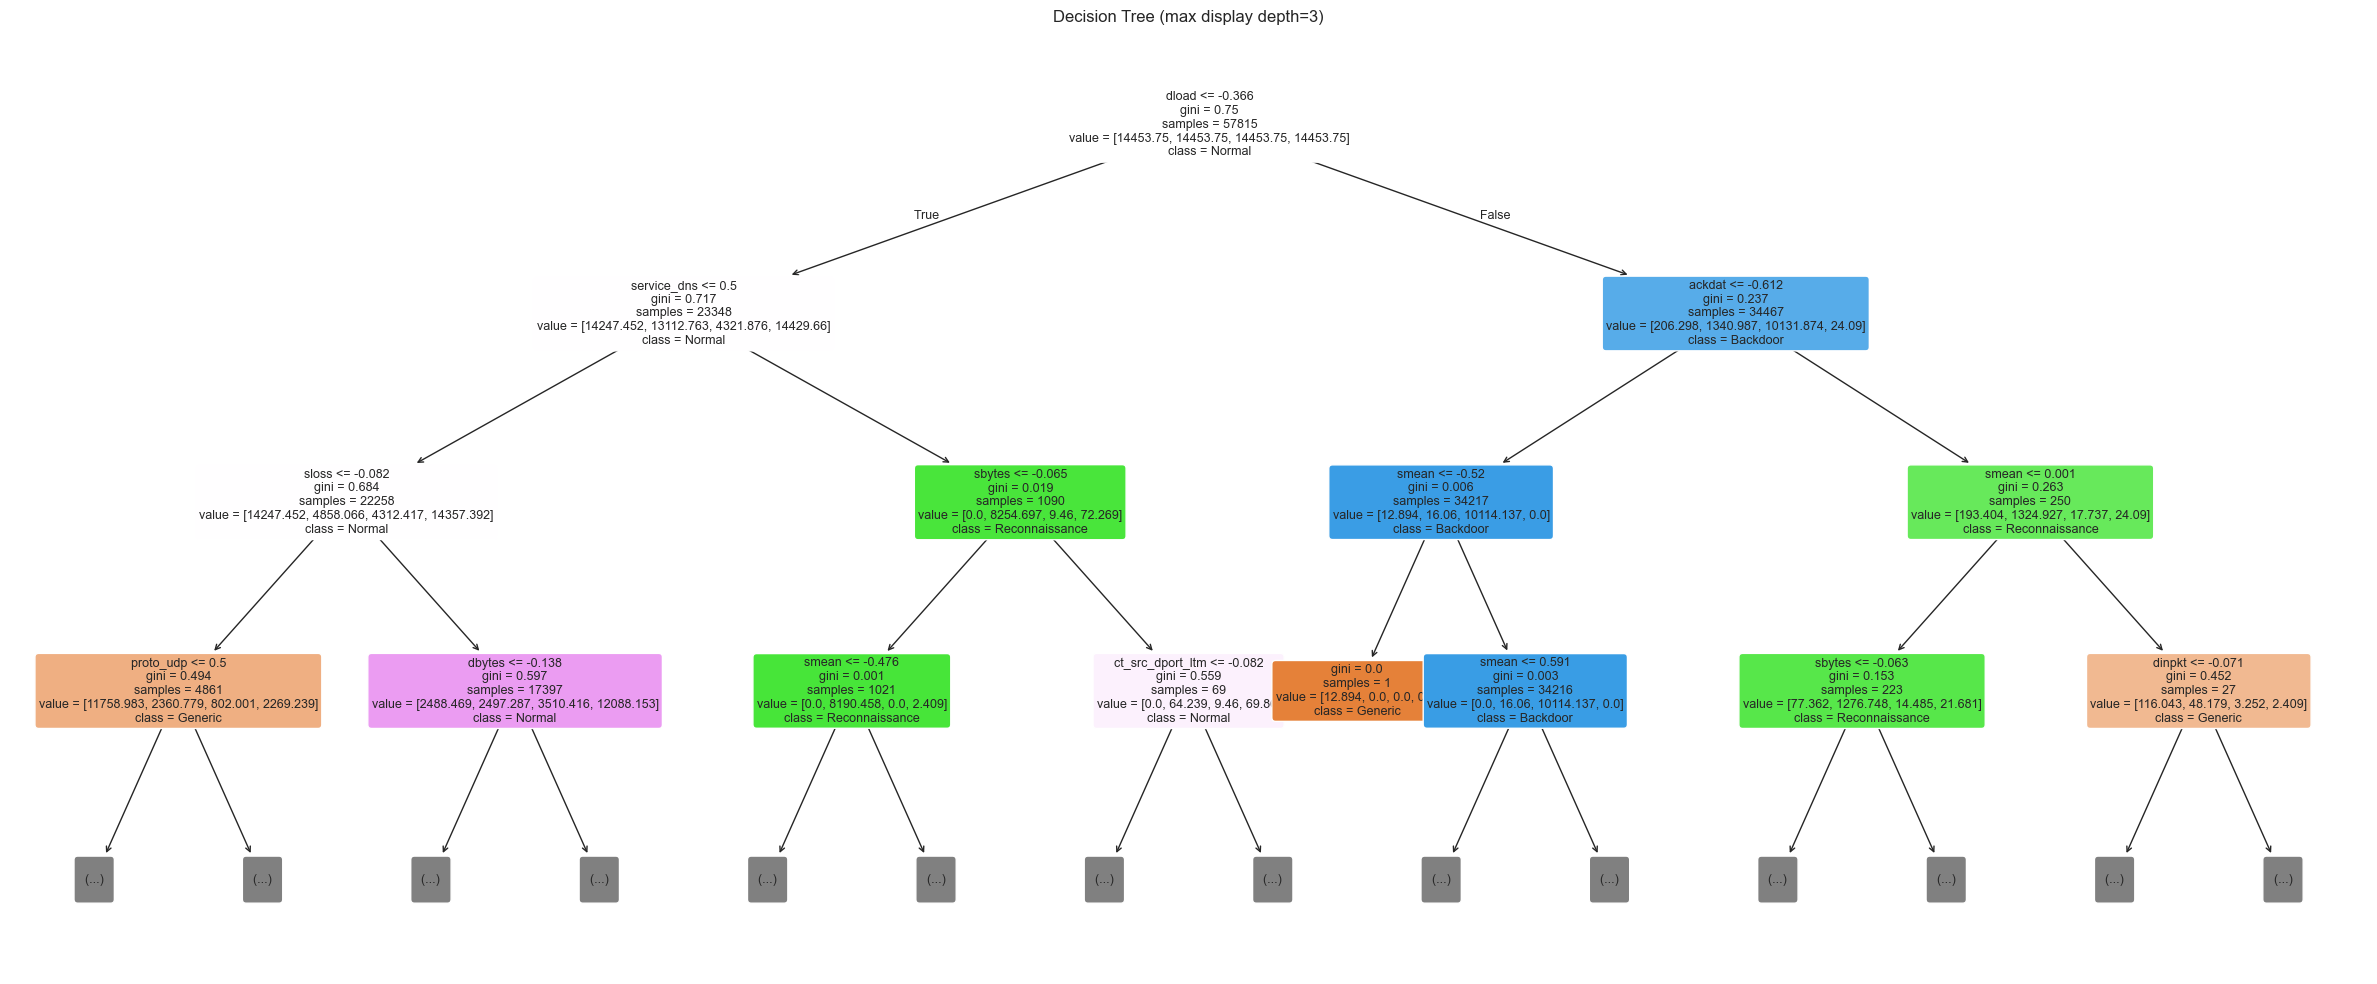

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_44904/2829940821.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r")


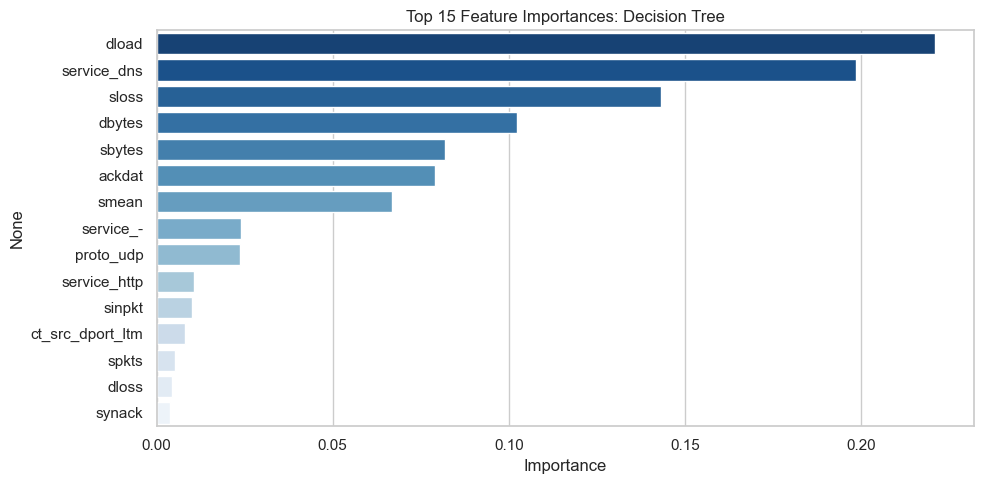

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree for attack type classification
dt_attack_clf = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=10
)
dt_attack_clf.fit(X_train_filtered, y_train_filtered)

# Predict and evaluate
y_pred_dt_attack = dt_attack_clf.predict(X_test_filtered)

print("Attack Type Classification: DecisionTreeClassifier")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_dt_attack):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_dt_attack):.4f}")

print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_dt_attack, zero_division=0))

cm_dt_attack = confusion_matrix(y_test_filtered, y_pred_dt_attack, labels=attack_types)
print("Confusion matrix:")
print(cm_dt_attack)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_attack, annot=True, fmt="d", cmap="Blues",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: Decision Tree Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot the decision tree (limited depth for readability)
plt.figure(figsize=(24, 10))
plot_tree(dt_attack_clf, max_depth=3, feature_names=X_train_filtered.columns,
          class_names=attack_types, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max display depth=3)")
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(dt_attack_clf.feature_importances_, index=X_train_filtered.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r")
plt.title("Top 15 Feature Importances: Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

/Users/mpersson/COMP9150/proj2/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [22:43:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Attack Type Classification: XGBClassifier
Accuracy: 0.9804
Balanced Accuracy: 0.8370

Classification report:
                precision    recall  f1-score   support

      Backdoor       0.53      0.61      0.56       296
       Generic       0.95      0.87      0.91      1643
        Normal       0.99      1.00      0.99     31610
Reconnaissance       0.92      0.87      0.90      2127

      accuracy                           0.98     35676
     macro avg       0.85      0.84      0.84     35676
  weighted avg       0.98      0.98      0.98     35676

Confusion matrix:
[[ 1427    30    19   167]
 [   14  1860   138   115]
 [    7    96   180    13]
 [   60    34     5 31511]]


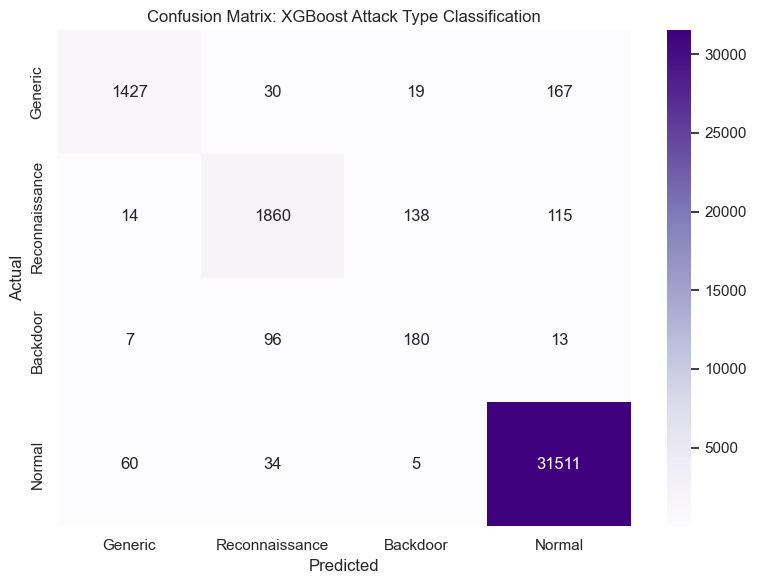

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_44904/2348815100.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette="Purples_r")


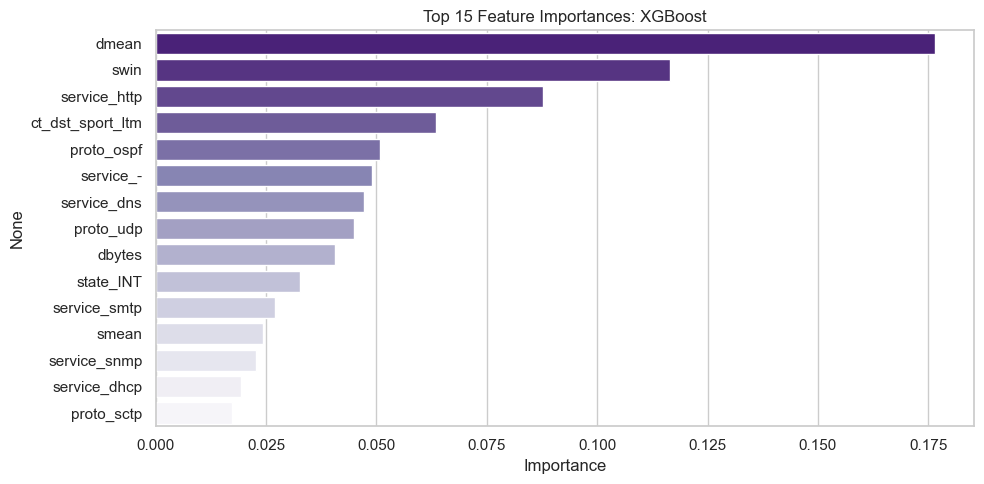

In [9]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Train XGBoost for attack type classification
xgb_attack_clf = XGBClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
le = LabelEncoder()
le.fit(attack_types)

y_train_encoded = le.transform(y_train_filtered)
y_test_encoded = le.transform(y_test_filtered)

xgb_attack_clf.fit(X_train_filtered, y_train_encoded)

# Predict and evaluate
y_pred_xgb_attack = le.inverse_transform(xgb_attack_clf.predict(X_test_filtered))

print("Attack Type Classification: XGBClassifier")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_xgb_attack):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_xgb_attack):.4f}")

print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_xgb_attack, zero_division=0))

cm_xgb_attack = confusion_matrix(y_test_filtered, y_pred_xgb_attack, labels=attack_types)
print("Confusion matrix:")
print(cm_xgb_attack)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_attack, annot=True, fmt="d", cmap="Purples",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: XGBoost Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Feature importances
importances_xgb = pd.Series(xgb_attack_clf.feature_importances_, index=X_train_filtered.columns)
top_features_xgb = importances_xgb.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette="Purples_r")
plt.title("Top 15 Feature Importances: XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

/Users/mpersson/COMP9150/proj2/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │       161,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,900 (831.64 KB)

 Trainable params: 212,900 (831.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9100 - loss: 0.3583 - val_accuracy: 0.3995 - val_loss: 3.0326
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9469 - loss: 0.1273 - val_accuracy: 0.4891 - val_loss: 4.1842
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9571 - loss: 0.1037 - val_accuracy: 0.5368 - val_loss: 4.3554
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9633 - loss: 0.0915 - val_accuracy: 0.5711 - val_loss: 4.2827
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9666 - loss: 0.0842 - val_accuracy: 0.5628 - val_loss: 4.8410
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9692 - loss: 0.0777 - val_accuracy: 0.5787 - val_loss: 4.9096
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9701 - loss: 0.0747 - val_accuracy: 0.5832 - val_loss: 5.3411
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9700 - loss: 0.0725 - val_accuracy: 0.

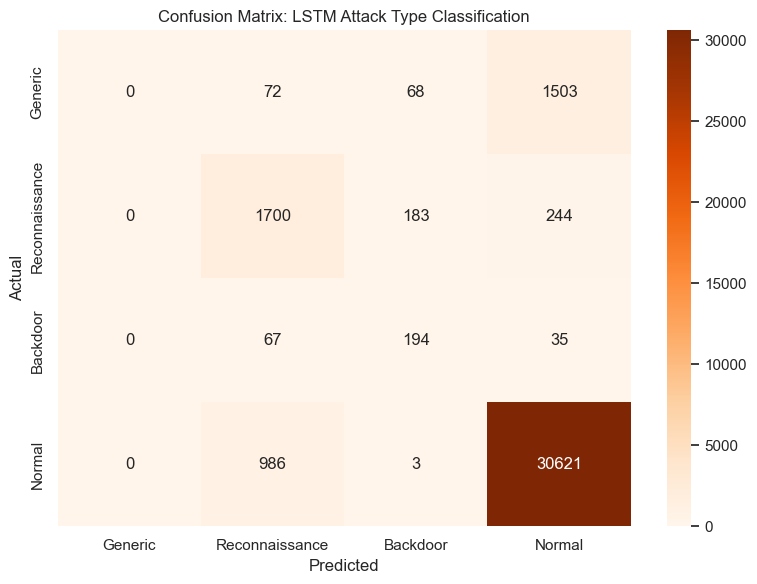

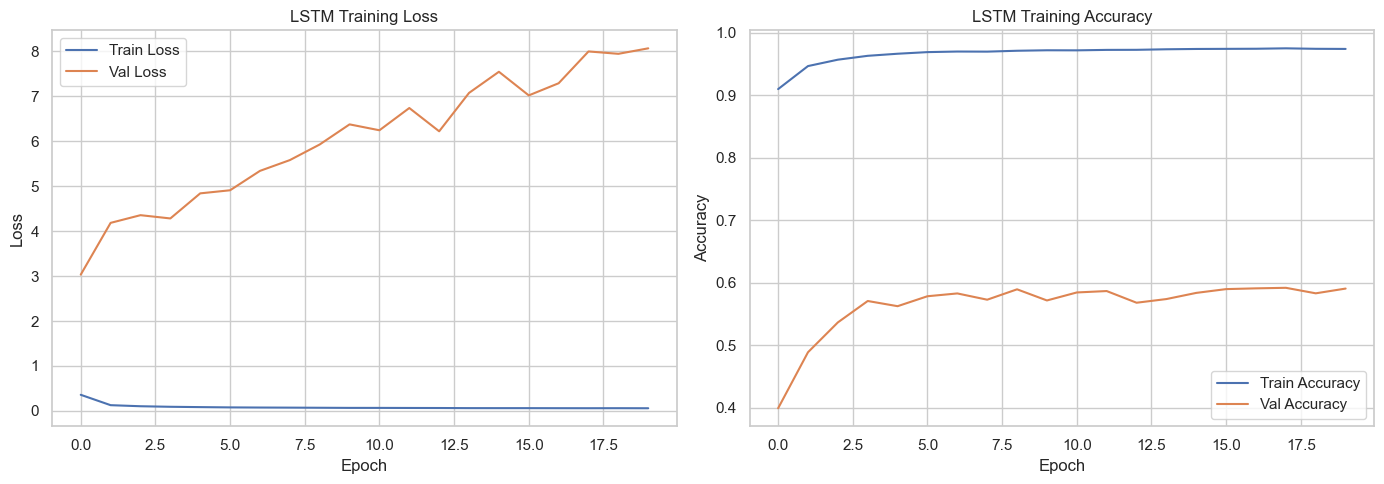

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# Prepare data: convert to numeric dtype and reshape for LSTM (samples, timesteps, features)
X_train_lstm = X_train_filtered.to_numpy(dtype=np.float32).reshape(
    (X_train_filtered.shape[0], 1, X_train_filtered.shape[1])
)
X_test_lstm = X_test_filtered.to_numpy(dtype=np.float32).reshape(
    (X_test_filtered.shape[0], 1, X_test_filtered.shape[1])
)

# Encode labels
le_lstm = LabelEncoder()
le_lstm.fit(attack_types)
y_train_lstm = to_categorical(
    le_lstm.transform(y_train_filtered), num_classes=len(attack_types)
).astype(np.float32)
y_test_lstm_encoded = le_lstm.transform(y_test_filtered)

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, input_shape=(1, X_train_filtered.shape[1]), return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(attack_types), activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# Train
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Predict
y_pred_lstm_probs = lstm_model.predict(X_test_lstm)
y_pred_lstm_encoded = np.argmax(y_pred_lstm_probs, axis=1)
y_pred_lstm = le_lstm.inverse_transform(y_pred_lstm_encoded)

print("Attack Type Classification: LSTM")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_lstm):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_lstm):.4f}")
print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_lstm, zero_division=0))

cm_lstm = confusion_matrix(y_test_filtered, y_pred_lstm, labels=attack_types)
print("Confusion matrix:")
print(cm_lstm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: LSTM Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()